# Sampling the Gaia [alpha/M] posterior

Regression follow-up to exp6: the ray tracing sampler on a small MLP
posterior over Gaia XP spectra, with the priors done right this time. This
is the reference notebook for the exp7 workbook; the run happened on a
RunPod 5090 (about 4 GPU hours total) on 2026-07-26/27.

### Read this first

- Data: the Laroche and Speagle pristine cut reproduced at 126,156 stars
  (paper: 123,804). Target: predict APOGEE [alpha/M] from the 110 XP
  coefficients. Model: MLP 110-64-64-1 tanh, D = 11,329. Likelihood:
  Gaussian per star with sigma = the APOGEE label error. T = 1.
- The prior is the story. A Glorot per-layer prior puts the typical set
  where order-one networks live: the chain starts on its shell, no walk.
  The same sampler under the exp6 N(0,1) prior starts 99 percent saturated
  and, on the same budget, ends at 2.9x the misfit with a predictive that
  barely matches k-NN (section 4).
- The sampled net beats the k-NN baseline: RMSE 0.049 vs 0.074 (section 7).
- Eq. 33 is never an informative filter here: blind at the start
  (sigma_sto 26M nats), correctly all-rejecting at the fitted state, and
  when tuned by the paper's recipe (dt 5e-6) its acceptance equals its own
  noise ceiling, coin flips that slow the chain 20x without stopping the
  norm creep (sections 5 and 6). Its value was diagnostic more than
  corrective; the chain of record keeps it regardless, and an unadjusted
  control arm reproduces its predictions to one percent.
- Calibration says the claimed uncertainties are at least 4x too small
  (6x on the chain of record, whose spread is a lower bound): the case for
  a learned intrinsic scatter of about 0.05 dex (section 7).

In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

ROOT = Path.cwd() if (Path.cwd() / "experiments").exists() else Path.cwd().parent
TAB = ROOT / "results" / "tables"
DEV = "mps" if torch.backends.mps.is_available() else "cpu"
LOG2PI = math.log(2 * math.pi)

plt.rcParams.update({
    "font.family": "STIXGeneral", "mathtext.fontset": "stix",
    "font.size": 11, "axes.labelsize": 11, "legend.fontsize": 9,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "xtick.minor.visible": True, "ytick.minor.visible": True,
    "axes.linewidth": 0.8, "lines.linewidth": 1.2,
    "legend.frameon": False, "figure.dpi": 115,
})
GRAY, DARK, ACCENT = "#8a8a8a", "#111111", "#b8860b"
BLUE = ACCENT  # accent alias kept so older cells read the same

d = np.load(TAB / "exp7_gaia_pristine.npz")
train_Xs, test_Xs = d["train_Xs"], d["test_Xs"]
train_y, test_y = d["train_y"], d["test_y"]
train_e, test_e = d["train_yerr"], d["test_yerr"]

CH_GATED_BLIND = TAB / "exp7_rt33_dt0.0001.npz"        # Glorot, descent, blind gate
CH_FROZEN     = TAB / "exp7_rt33_dt0.0001_part2.npz"   # all-reject leg
CH_UNGATED    = TAB / "exp7_rtub_dt0.0001.npz"         # Glorot, ungated control
CH_GATED_5E6  = TAB / "exp7_rt33_dt5e-06.npz"          # Glorot, working gate
CH_NORMAL     = TAB / "exp7n_rt33_dt0.0001.npz"        # N(0,1), same budget

def make_model():
    torch.manual_seed(0)
    return nn.Sequential(nn.Linear(110, 64), nn.Tanh(),
                         nn.Linear(64, 64), nn.Tanh(),
                         nn.Linear(64, 1)).to(DEV)

def glorot_sigmas(model, bias_sigma=0.1):
    return [math.sqrt(2.0 / (p.shape[1] + p.shape[0])) if p.ndim == 2
            else bias_sigma for p in model.parameters()]

def load_flat(model, flat):
    flat = torch.tensor(flat, dtype=torch.float32, device=DEV)
    i = 0
    with torch.no_grad():
        for p in model.parameters():
            p.copy_(flat[i:i + p.numel()].view(p.shape))
            i += p.numel()

@torch.no_grad()
def predictive(files, members=50):
    """Member predictions on the test split from the final quarter."""
    snaps = np.concatenate([np.load(f)["snapshots"] for f in files])
    quarter = snaps[3 * len(snaps) // 4:]
    take = np.linspace(0, len(quarter) - 1, min(members, len(quarter))).astype(int)
    model, X = make_model(), torch.tensor(test_Xs, device=DEV)
    mus = []
    for s in quarter[take]:
        load_flat(model, s)
        mus.append(model(X).squeeze(-1).cpu().numpy())
    mus = np.stack(mus)
    return mus.mean(axis=0), mus.std(axis=0)

D = sum(p.numel() for p in make_model().parameters())
print(f"train {len(train_Xs):,}  test {len(test_Xs):,}  D = {D:,}  device {DEV}")

train 100,924  test 25,232  D = 11,329  device mps


## 1. The sample

The paper's pristine cut, reproduced from its Section 2.2 recipe (label
precision, color, magnitude, and flag cuts; no Teff or logg cut, cool
giants emerge): 502,311 crossmatch, 126,156 pristine here vs 123,804 in the
paper. Split 80/20 with seed 2003, coefficients standardized on the
training split. The labels carry a median error of 0.006 against a spread
of 0.093: a factor 15 of usable information per star.

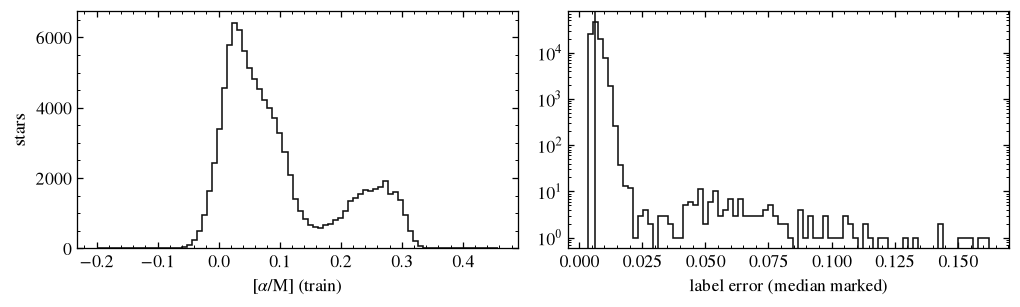

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(9, 2.8))
axes[0].hist(train_y, bins=80, histtype="step", color=DARK)
axes[0].set_xlabel(r"[$\alpha$/M] (train)")
axes[0].set_ylabel("stars")
axes[1].hist(train_e, bins=80, histtype="step", color=DARK, log=True)
axes[1].axvline(np.median(train_e), color=DARK, lw=1)
axes[1].set_xlabel("label error (median marked)")
fig.tight_layout()

## 2. The target

$$\ln p(\theta \mid \mathcal{D}) = -\Big[\sum_i
\frac{(y_i - \mu_\theta(x_i))^2}{2\,\mathrm{err}_i^2}
+ \ln \mathrm{err}_i + \tfrac{1}{2}\ln 2\pi\Big]
- \tfrac{1}{2}\sum_j \frac{\theta_j^2}{\sigma_j^2} + \text{const}$$

Gaussian likelihood with each star's own APOGEE error as sigma, T = 1,
and a per-layer Gaussian prior. The only difference from exp6 is the
likelihood line and the sigma vector; the sampler machinery is identical.

## 3. What each prior believes, before any data

Twenty networks drawn from each prior, run on the held-out spectra. The
N(0,1) prior (exp6's choice) drives every first-layer preactivation to
about 10 standard deviations, saturating every tanh: its typical network
is a random switchboard predicting order 10 when the labels span 0.6.
Glorot's variance, 2/(fan_in + fan_out), is precisely the choice that
keeps signals order one, so its prior predictive lands on the right scale
by construction. Same geometry, shells at raw norm-squared 11,329 vs 148,
just placed where different networks live.

typical |prediction|: N(0,1) 5.13, Glorot 0.29, labels 0.07


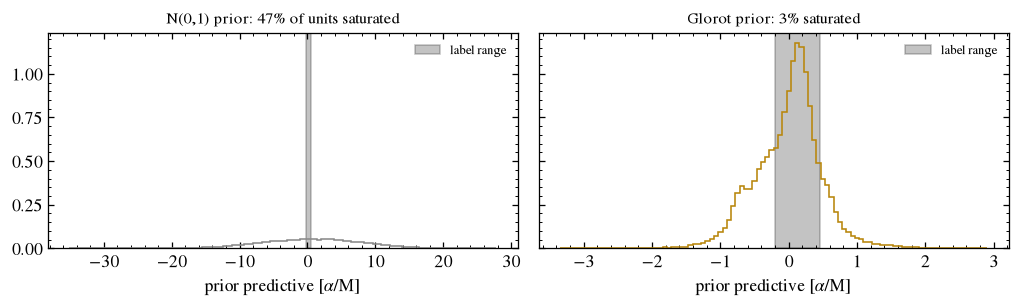

In [3]:
def prior_preds(sigmas_fn, n_draws=20):
    model = make_model()
    X = torch.tensor(test_Xs[:5000], device=DEV)
    sig = sigmas_fn(model)
    preds, sat = [], []
    g = torch.Generator(device="cpu").manual_seed(1)
    with torch.no_grad():
        for k in range(n_draws):
            for p, s in zip(model.parameters(), sig):
                p.copy_(torch.randn(p.shape, generator=g).to(DEV) * s)
            h = torch.tanh(model[0](X))
            sat.append((h.abs() > 0.99).float().mean().item())
            preds.append(model(X).squeeze(-1).cpu().numpy())
    return np.concatenate(preds), np.mean(sat)

pred_n, sat_n = prior_preds(lambda m: [1.0] * len(list(m.parameters())))
pred_g, sat_g = prior_preds(glorot_sigmas)

fig, axes = plt.subplots(1, 2, figsize=(9, 2.8), sharey=True)
axes[0].hist(pred_n, bins=100, histtype="step", color=GRAY, density=True)
axes[0].set_title(f"N(0,1) prior: {100*sat_n:.0f}% of units saturated", fontsize=10)
axes[1].hist(pred_g, bins=100, histtype="step", color=ACCENT, density=True)
axes[1].set_title(f"Glorot prior: {100*sat_g:.0f}% saturated", fontsize=10)
for ax in axes:
    ax.axvspan(train_y.min(), train_y.max(), color=DARK, alpha=0.25,
               label="label range")
    ax.set_xlabel(r"prior predictive [$\alpha$/M]")
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
print(f"typical |prediction|: N(0,1) {np.median(np.abs(pred_n)):.2f}, "
      f"Glorot {np.median(np.abs(pred_g)):.2f}, labels {np.median(np.abs(train_y)):.2f}")

## 4. Same sampler, same budget, two priors

The experiment: two chains with identical settings (minibatch Raytracer,
batch 1024, dt 1e-4, Eq. 33 checkpoints every 30 steps), each started from
a draw of its own prior, 500,000 steps each. The Glorot chain starts on
its shell and spends the budget fitting. The N(0,1) chain starts with 99
percent of its first-layer units saturated, where gradients are feeble,
and it shows: after the same 500,000 steps it sits at 2.9x the misfit
(4.78M vs 1.64M nats) with held-out RMSE 0.070, barely ahead of the k-NN
baseline the deep model is supposed to beat, against Glorot's 0.049. Both
chains sit faithfully on their own prior shells (right panel); the
difference is purely which networks live there. The prior is not a
detail: it decides what the entire budget buys.

final misfit: Glorot 1,644,134  N(0,1) 4,779,116


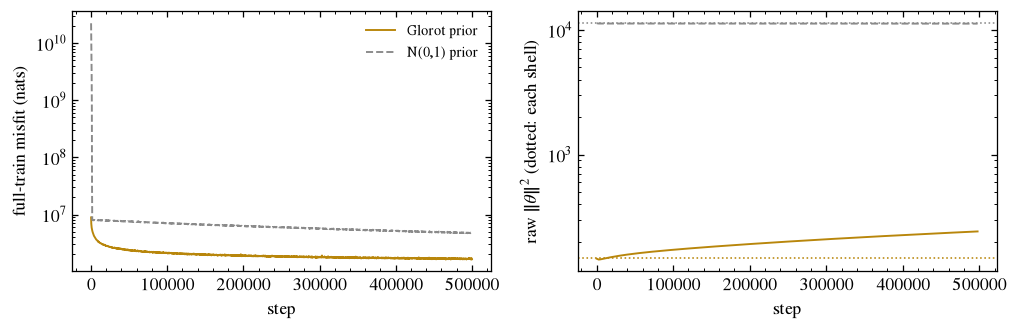

In [4]:
g1 = np.load(CH_GATED_BLIND)
n1 = np.load(CH_NORMAL)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.0))
axes[0].semilogy(g1["steps"], g1["misfit"], color=BLUE, label="Glorot prior")
axes[0].semilogy(n1["steps"], n1["misfit"], color=GRAY, ls="--", label="N(0,1) prior")
axes[0].set_xlabel("step")
axes[0].set_ylabel("full-train misfit (nats)")
axes[0].legend(frameon=False, fontsize=9)

sig_g = glorot_sigmas(make_model())
shell_glorot = sum(s**2 * n for s, n in zip(
    sig_g, [p.numel() for p in make_model().parameters()]))
rn_g = np.array([float((torch.tensor(s)**2).sum()) for s in g1["snapshots"][::10]])
rn_n = np.array([float((torch.tensor(s)**2).sum()) for s in n1["snapshots"][::10]])
axes[1].semilogy(g1["steps"][::10], rn_g, color=BLUE)
axes[1].semilogy(n1["steps"][::10], rn_n, color=GRAY, ls="--")
axes[1].axhline(shell_glorot, color=BLUE, ls=":", lw=1)
axes[1].axhline(11329, color=GRAY, ls=":", lw=1)
axes[1].set_xlabel("step")
axes[1].set_ylabel(r"raw $\|\theta\|^2$ (dotted: each shell)")
fig.tight_layout()
print(f"final misfit: Glorot {g1['misfit'][-1]:,.0f}  "
      f"N(0,1) {n1['misfit'][-1]:,.0f}")

## 5. The Eq. 33 gate: blind, then correct, then tuned

The gate compares a fresh one-batch estimate of the log posterior against
the sampler's own luminosity ledger every 30 steps, softened by
1/sqrt(1 + sigma_sto^2). Three regimes, all observed:

At the prior draw sigma_sto is 26M nats (the fit is terrible, batches
disagree wildly), the exponent is 4e-8, and the gate accepts everything.
At the fitted state sigma_sto drops to 135k, and at dt 1e-4 the gate
rejects every window: the ledger claims about 10M nats per window that
the estimates never see. Real irreversibility, correctly caught (left
panel). Lowering dt until acceptance recovers (the paper's own recipe,
applied at the fitted state where it can work) lands at dt = 5e-6 with
acceptance 0.36 (right panel). The plateau at 0.38 for smaller dt is the
gate's noise ceiling: with two independent batch estimates per window,
even a perfect chain loses 62 percent of its windows.

frozen leg: mean window ratio -10,317,504 nats, sigma_sto 135,305, acceptance 0.00


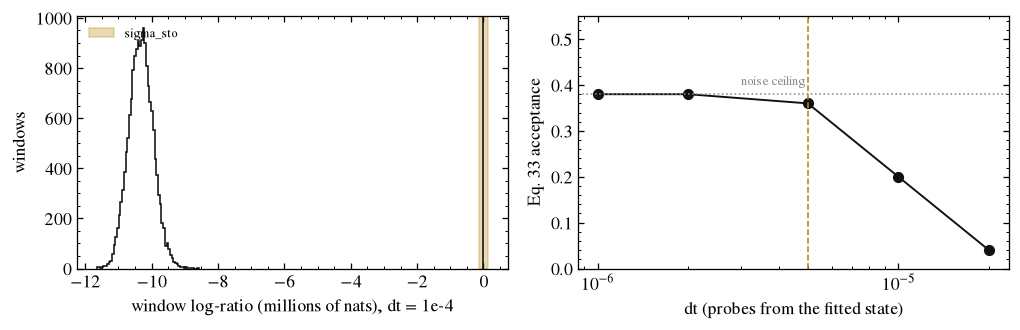

In [5]:
fr = np.load(CH_FROZEN)
raw = fr["window_raw"] / 1e6
sigma_sto = float(fr["sigma_sto"])

fig, axes = plt.subplots(1, 2, figsize=(9, 3.0))
axes[0].hist(raw, bins=60, histtype="step", color=DARK)
axes[0].axvline(0, color=DARK, lw=1)
axes[0].axvspan(-sigma_sto / 1e6, sigma_sto / 1e6, color=BLUE, alpha=0.3,
                label="sigma_sto")
axes[0].set_xlabel("window log-ratio (millions of nats), dt = 1e-4")
axes[0].set_ylabel("windows")
axes[0].legend(loc="upper left", fontsize=8)

dts = [2e-5, 1e-5, 5e-6, 2e-6, 1e-6]
accs = [0.04, 0.20, 0.36, 0.38, 0.38]
axes[1].semilogx(dts, accs, "o-", color=DARK)
axes[1].axhline(0.38, color=GRAY, ls=":", lw=1)
axes[1].annotate("noise ceiling", (3e-6, 0.40), fontsize=8, color=GRAY)
axes[1].axvline(5e-6, color=BLUE, ls="--", lw=1)
axes[1].set_xlabel("dt (probes from the fitted state)")
axes[1].set_ylabel("Eq. 33 acceptance")
axes[1].set_ylim(0, 0.55)
fig.tight_layout()
print(f"frozen leg: mean window ratio {raw.mean()*1e6:,.0f} nats, "
      f"sigma_sto {sigma_sto:,.0f}, acceptance {fr['window_accepted'].mean():.2f}")

## 6. The gated production chain at dt = 5e-6

Two million steps from the fitted state at the tuned step size. The
verdict is subtle: acceptance holds at 0.38, which is exactly the noise
ceiling from section 5, so the gate's decisions are statistically
indistinguishable from coin flips. It slows the chain (20x smaller steps,
62 percent of windows rejected at random) without policing anything: the
weighted norm still creeps, 19.2k to 24.4k over the two million steps.
And the price shows up in the members: the final-quarter spread collapses
to 0.002 because the chain barely moves. The honest reading: on this
target Eq. 33 is a diagnostic (its all-reject verdict at dt 1e-4 was
correct and useful) more than a filter. This chain, gate and all, is the
chain of record for everything downstream; its collapsed spread is
treated as a lower bound wherever it appears.

steps 2,000,000  acceptance 0.38  final misfit 1,405,228  final wnorm 24,399


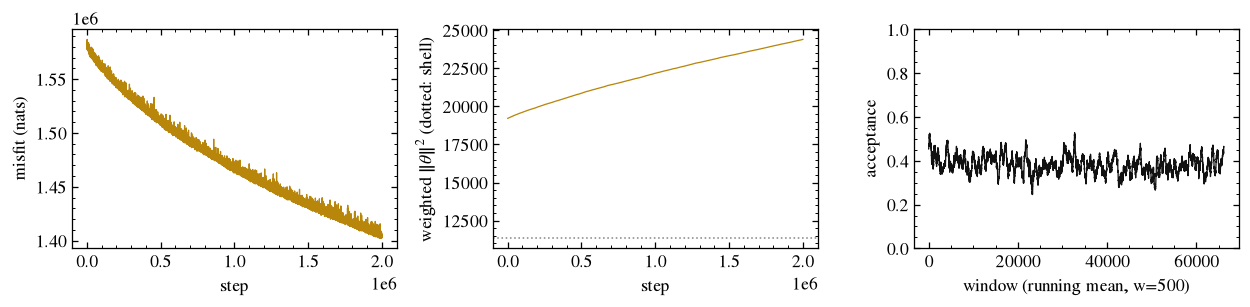

In [6]:
pr = np.load(CH_GATED_5E6)
fig, axes = plt.subplots(1, 3, figsize=(11, 2.8))
axes[0].plot(pr["steps"], pr["misfit"], color=BLUE, lw=0.8)
axes[0].set_xlabel("step"); axes[0].set_ylabel("misfit (nats)")
axes[1].plot(pr["steps"], pr["wnorm"], color=BLUE, lw=0.8)
axes[1].axhline(11329, color=GRAY, ls=":", lw=1)
axes[1].set_xlabel("step"); axes[1].set_ylabel(r"weighted $\|\theta\|^2$ (dotted: shell)")
acc = pr["window_accepted"].astype(float)
w = 500
run_acc = np.convolve(acc, np.ones(w) / w, mode="valid")
axes[2].plot(run_acc, color=DARK, lw=0.8)
axes[2].set_xlabel(f"window (running mean, w={w})")
axes[2].set_ylabel("acceptance")
axes[2].set_ylim(0, 1)
fig.tight_layout()
print(f"steps {int(pr['n_steps']):,}  acceptance {acc.mean():.2f}  "
      f"final misfit {pr['misfit'][-1]:,.0f}  final wnorm {pr['wnorm'][-1]:,.0f}")

## 7. Scorecard

Held-out RMSE, then calibration for the chain of record: the gated
dt = 5e-6 chain, Metropolis-checked end to end. An unadjusted control arm
reproduces its predictions to one percent (printed under the table), and
the N(0,1) row is the prior ablation of section 4. The sampled network
beats k-NN by a third. Calibration: the z scores should be N(0,1) if the
total claimed uncertainty (member spread plus label error) means
anything; they are about 6x too wide. The member spread under the gate is
a lower bound (slow mixing), but even the control arm's generous spread
leaves z at 4.4, so the conclusion survives the caveat: residual RMSE
0.049 against claimed uncertainties of ~0.01 is the case for a learned
intrinsic scatter s of about 0.05 dex.

In [7]:
k = 10
Xtr = torch.tensor(train_Xs, device=DEV)
Xte = torch.tensor(test_Xs, device=DEV)
ytr = torch.tensor(train_y, device=DEV)
knn = torch.empty(len(test_Xs))
for i in range(0, len(test_Xs), 1024):
    dist = torch.cdist(Xte[i:i + 1024], Xtr)
    _, idx = torch.topk(dist, k, largest=False)
    knn[i:i + 1024] = ytr[idx].mean(dim=1).cpu()
knn = knn.numpy()

rows = {"global mean": np.full(len(test_y), train_y.mean()), "k-NN (k=10)": knn}
mu_n, tau_n = predictive([CH_NORMAL]);       rows["N(0,1) chain"] = mu_n
mu_p, tau_p = predictive([CH_GATED_5E6]);    rows["the chain (gated 5e-6)"] = mu_p

print(f"{'method':>22}  RMSE")
for name, mu in rows.items():
    print(f"{name:>22}  {np.sqrt(np.mean((mu - test_y) ** 2)):.4f}")
mu_u, tau_u = predictive([CH_UNGATED])
print(f"(unadjusted control arm agrees: "
      f"RMSE {np.sqrt(np.mean((mu_u - test_y) ** 2)):.4f}, "
      f"mean |pred difference| {np.abs(mu_u - mu_p).mean():.4f})")

                method  RMSE
           global mean  0.0927
           k-NN (k=10)  0.0742
          N(0,1) chain  0.0704
the chain (gated 5e-6)  0.0492
(unadjusted control arm agrees: RMSE 0.0486, mean |pred difference| 0.0038)


member spread (median): chain 0.0019 (lower bound), control 0.0079; median label err 0.0064


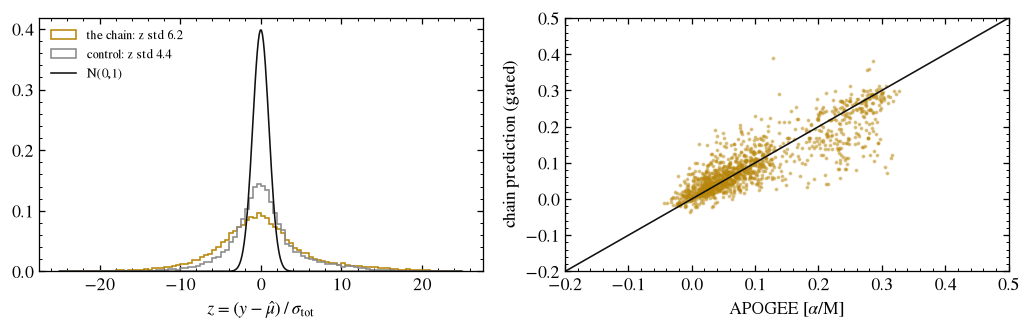

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.0))
for mu, tau, c, label in ((mu_p, tau_p, BLUE, "the chain"),
                          (mu_u, tau_u, GRAY, "control")):
    z = (test_y - mu) / np.sqrt(tau ** 2 + test_e ** 2)
    axes[0].hist(z, bins=100, range=(-25, 25), density=True, histtype="step",
                 color=c, label=f"{label}: z std {z.std():.1f}")
grid = np.linspace(-25, 25, 400)
axes[0].plot(grid, np.exp(-grid**2 / 2) / np.sqrt(2 * np.pi), color=DARK, lw=1,
             label="N(0,1)")
axes[0].set_xlabel(r"$z = (y - \hat{\mu})\,/\,\sigma_{\rm tot}$")
axes[0].legend(loc="upper left", fontsize=8)

axes[1].scatter(test_y[::20], mu_p[::20], s=2, color=BLUE, alpha=0.4)
lims = (-0.2, 0.5)
axes[1].plot(lims, lims, color=DARK, lw=1)
axes[1].set_xlim(lims); axes[1].set_ylim(lims)
axes[1].set_xlabel(r"APOGEE [$\alpha$/M]")
axes[1].set_ylabel("chain prediction (gated)")
fig.tight_layout()
print(f"member spread (median): chain {np.median(tau_p):.4f} (lower bound), "
      f"control {np.median(tau_u):.4f}; median label err {np.median(test_e):.4f}")

## 8. Looking at the spectra (GaiaXpy)

GaiaXpy turns the 110 coefficients back into calibrated flux against
wavelength (the first 55 are BP: swapping the halves produces a seam at
640 nm, so the order is confirmed). Calibration is linear in the
coefficients, which buys the third panel below: the network's input
gradient can itself be calibrated like a spectrum, giving the model's
sensitivity in wavelength space. Where the data says alpha lives (matched
stacks) and where the network looks (saliency) agree: the blue end.

Calibrating data:   0%|          | 0/107 [00:00<?, ?spec/s]

Calibrating data:   0%|          | 0/250 [00:00<?, ?spec/s]

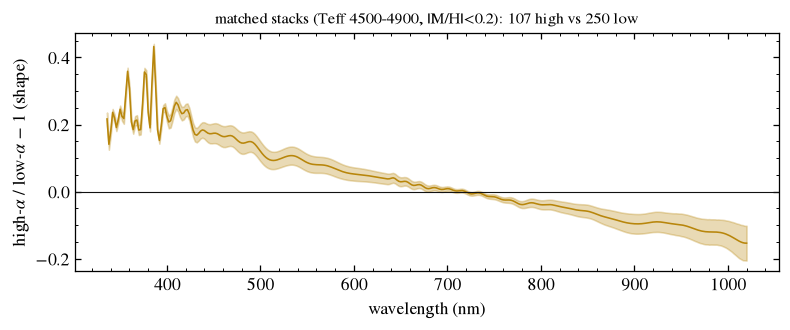

In [9]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
from gaiaxpy import calibrate
plt.rcParams.update({"text.usetex": False})

sp = np.load(TAB / "exp7_gaia_spectra_payload.npz")
ZCORR = np.zeros(55 * 54 // 2)

def calib(rows_local, coeff_override=None):
    recs = []
    for j, r in enumerate(rows_local):
        c = sp["coeffs"][r] if coeff_override is None else coeff_override
        e = np.abs(sp["coeff_errs"][r]) + 1e-30
        recs.append(dict(source_id=int(sp["sids"][r]),
                         bp_n_parameters=55, rp_n_parameters=55,
                         bp_standard_deviation=1.0, rp_standard_deviation=1.0,
                         bp_coefficients=c[:55].astype(np.float64),
                         bp_coefficient_errors=e[:55].astype(np.float64),
                         bp_coefficient_correlations=ZCORR,
                         rp_coefficients=c[55:].astype(np.float64),
                         rp_coefficient_errors=e[55:].astype(np.float64),
                         rp_coefficient_correlations=ZCORR))
    cal, sampling = calibrate(pd.DataFrame.from_records(recs), save_file=False)
    return sampling, np.stack(cal["flux"].to_numpy()), np.stack(cal["flux_error"].to_numpy())

# matched stacks: same Teff and [M/H] box, split by alpha, shape only
box = ((sp["teff"] > 4500) & (sp["teff"] < 4900)
       & (sp["mh"] > -0.2) & (sp["mh"] < 0.2))
hi = np.flatnonzero(box & (test_y > 0.20))[:250]
lo = np.flatnonzero(box & (test_y < 0.06))[:250]
wl, fh, _ = calib(hi)
_, fl, _ = calib(lo)
fh /= fh.mean(axis=1, keepdims=True)
fl /= fl.mean(axis=1, keepdims=True)
rel = fh.mean(axis=0) / fl.mean(axis=0) - 1
rel_err = np.sqrt(fh.std(axis=0)**2 / len(fh) + fl.std(axis=0)**2 / len(fl))

fig, ax = plt.subplots(figsize=(7, 3.0))
ax.fill_between(wl, rel - rel_err, rel + rel_err, color=BLUE, alpha=0.3)
ax.plot(wl, rel, color=BLUE, lw=1)
ax.axhline(0, color=DARK, lw=0.7)
ax.set_xlabel("wavelength (nm)")
ax.set_ylabel(r"high-$\alpha$ / low-$\alpha$ $-$ 1 (shape)")
ax.set_title(f"matched stacks (Teff 4500-4900, |M/H|<0.2): "
             f"{len(hi)} high vs {len(lo)} low", fontsize=10)
fig.tight_layout()

Calibrating data:   0%|          | 0/1 [00:00<?, ?spec/s]

Calibrating data:   0%|          | 0/1 [00:00<?, ?spec/s]

star card: APOGEE +0.068 +- 0.006, chain +0.054 +- 0.002 (the calibration gap, one star at a time)


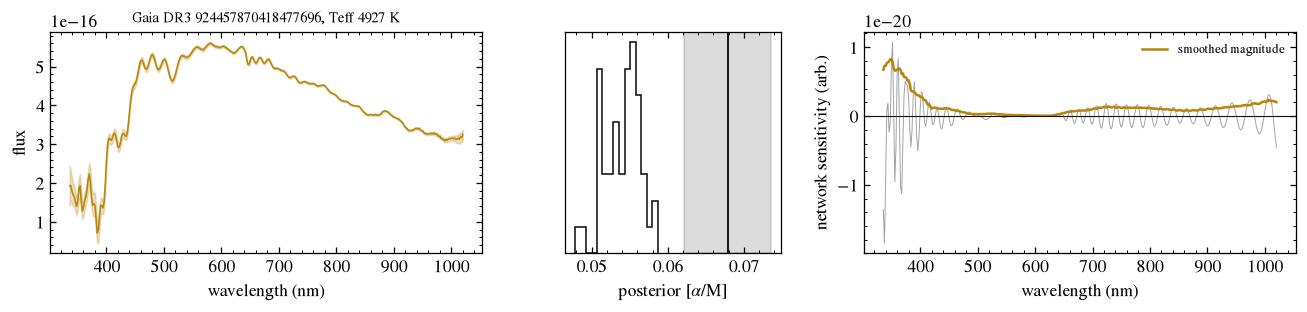

In [10]:
# star card: one giant's spectrum plus the chain's posterior for it,
# and the network saliency in wavelength space (linearity trick)
star = int(np.argsort(np.abs(test_y - np.median(test_y)))[0])
snaps_ub = np.load(CH_GATED_5E6)["snapshots"]
q = snaps_ub[3 * len(snaps_ub) // 4:]
model = make_model().cpu()
preds, grads = [], []
for s in q[np.linspace(0, len(q) - 1, 50).astype(int)]:
    i = 0
    with torch.no_grad():
        for p in model.parameters():
            p.copy_(torch.tensor(s[i:i + p.numel()]).view(p.shape)); i += p.numel()
    x = torch.tensor(test_Xs[star:star + 1]).requires_grad_(True)
    out = model(x).squeeze(); out.backward()
    preds.append(float(out)); grads.append(x.grad.numpy().ravel().copy())
preds = np.array(preds)
graw = np.mean(grads, axis=0) / d["norm_sd"]

wl, fs, fe = calib([star])
_, sal, _ = calib([star], coeff_override=graw)
sal = sal[0]

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.0),
                         width_ratios=[2.2, 1.1, 2.2])
axes[0].fill_between(wl, fs[0] - fe[0], fs[0] + fe[0], color=ACCENT, alpha=0.25)
axes[0].plot(wl, fs[0], color=ACCENT, lw=1)
axes[0].set_xlabel("wavelength (nm)"); axes[0].set_ylabel("flux")
axes[0].set_title(f"Gaia DR3 {sp['sids'][star]}, Teff {sp['teff'][star]:.0f} K",
                  fontsize=9)
axes[1].hist(preds, bins=15, histtype="step", color=DARK)
axes[1].axvline(test_y[star], color=DARK, lw=1.2)
axes[1].axvspan(test_y[star] - test_e[star], test_y[star] + test_e[star],
                color=DARK, alpha=0.15)
axes[1].set_xlabel(r"posterior [$\alpha$/M]")
axes[1].set_yticks([])
axes[2].plot(wl, sal, color=GRAY, lw=0.6, alpha=0.8)
w = 15
axes[2].plot(wl, np.sqrt(np.convolve(sal**2, np.ones(w) / w, mode="same")),
             color=ACCENT, lw=1.6, label="smoothed magnitude")
axes[2].axhline(0, color=DARK, lw=0.7)
axes[2].legend(fontsize=8)
axes[2].set_xlabel("wavelength (nm)")
axes[2].set_ylabel("network sensitivity (arb.)")
fig.tight_layout()
print(f"star card: APOGEE {test_y[star]:+.3f} +- {test_e[star]:.3f}, "
      f"chain {preds.mean():+.3f} +- {preds.std():.3f} "
      f"(the calibration gap, one star at a time)")

## 9. The corrected noise model: the intrinsic-scatter run

The calibration verdict of section 7 says the likelihood's claim, that the
network can match every label to its quoted APOGEE error, is false. The
correction is one new sampled parameter: var_i = err_i^2 + s^2, with
ln s = -3 + u and u given a N(0,1) prior, so s starts at 0.0498, the
measured residual level. D becomes 11,330. The run continues from the
gated chain's endpoint, retuned on the corrected target.

Two things happened before the run even finished tuning. sigma_sto stayed
high, 162k nats: the star-to-star misfit spread is owned by a small tail
of stars the network misses by half a dex, and one global s cannot
describe them (a heavy-tailed likelihood is the eventual fix, a modeling
decision beyond this run). But the acceptance ladder came alive anyway:
0.83 / 0.90 / 0.94 / 0.92 for dt from 1e-4 down to 1e-5. A gate whose
answer finally depends on the step size is discriminating, not coin
flipping; fixing the noise model shrank the gradients themselves (one
over 0.05 squared instead of one over 0.006 squared per star), so the
per-window bookkeeping error collapsed into the range the softened test
can adjudicate. The production run below: dt 2e-5, four times the old
step, at ~0.9 acceptance instead of 0.38 coin flips.

drift misfit: +90.31 vs noise 2517 (level)
drift wnorm: -13.27 vs noise 303.8 (level)
drift s_trace: +6.594e-05 vs noise 0.000984 (level)
s: median 0.0462 (started 0.0498; residual prediction 0.049), member spread 0.0013
RMSE 0.2938 (k-NN 0.0742)   z std 0.616 (1.0 = calibrated)   median member spread 0.1458
acceptance 0.99 at dt 2e-5 (previous chain: 0.38 coin flips at dt 5e-6)


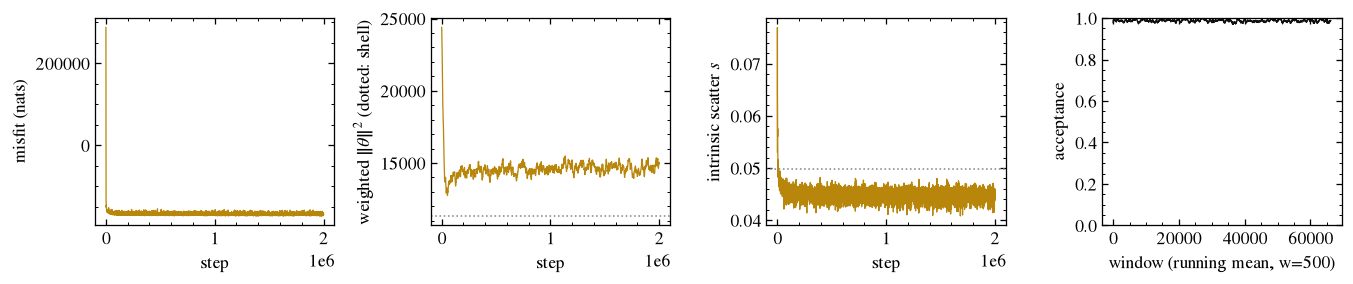

In [11]:
sc = np.load(TAB / "exp7s_rt33_dt2e-05.npz")
LNS0 = -3.0

fig, axes = plt.subplots(1, 4, figsize=(12, 2.6))
axes[0].plot(sc["steps"], sc["misfit"], color=BLUE, lw=0.8)
axes[0].set_xlabel("step"); axes[0].set_ylabel("misfit (nats)")
axes[1].plot(sc["steps"], sc["wnorm"], color=BLUE, lw=0.8)
axes[1].axhline(11330, color=GRAY, ls=":", lw=1)
axes[1].set_xlabel("step"); axes[1].set_ylabel(r"weighted $\|\theta\|^2$ (dotted: shell)")
axes[2].plot(sc["steps"], sc["s_trace"], color=ACCENT, lw=0.8)
axes[2].axhline(0.0498, color=GRAY, ls=":", lw=1)
axes[2].set_xlabel("step"); axes[2].set_ylabel(r"intrinsic scatter $s$")
acc = sc["window_accepted"].astype(float)
w = 500
axes[3].plot(np.convolve(acc, np.ones(w) / w, mode="valid"), color=DARK, lw=0.8)
axes[3].set_xlabel(f"window (running mean, w={w})")
axes[3].set_ylabel("acceptance"); axes[3].set_ylim(0, 1)
fig.tight_layout()

# predictive with the sampled scatter: snapshots are 11,330 long, u last
snaps = sc["snapshots"]
quarter = snaps[3 * len(snaps) // 4:]
take = np.linspace(0, len(quarter) - 1, 50).astype(int)
model = make_model()
mus, s_members = [], []
with torch.no_grad():
    X = torch.tensor(test_Xs, device=DEV)
    for st in quarter[take]:
        load_flat(model, st[:-1])
        mus.append(model(X).squeeze(-1).cpu().numpy())
        s_members.append(math.exp(LNS0 + float(st[-1])))
mus = np.stack(mus); s_members = np.array(s_members)
mu_s, tau_s = mus.mean(axis=0), mus.std(axis=0)
s_med = float(np.median(s_members))
var_tot = tau_s**2 + test_e**2 + s_med**2
z = (test_y - mu_s) / np.sqrt(var_tot)
rmse = float(np.sqrt(np.mean((mu_s - test_y) ** 2)))

def drift(series):
    q = series[3 * len(series) // 4:]
    dr = np.polyfit(np.arange(len(q)), q, 1)[0] * len(q)
    return dr, q.std(), "level" if abs(dr) < 2 * q.std() else "moving"

for name in ("misfit", "wnorm", "s_trace"):
    dr, no, verdict = drift(sc[name])
    print(f"drift {name}: {dr:+.4g} vs noise {no:.4g} ({verdict})")
print(f"s: median {s_med:.4f} (started 0.0498; residual prediction 0.049), "
      f"member spread {s_members.std():.4f}")
print(f"RMSE {rmse:.4f} (k-NN 0.0742)   z std {z.std():.3f} (1.0 = calibrated)   "
      f"median member spread {np.median(tau_s):.4f}")
print(f"acceptance {acc.mean():.2f} at dt 2e-5 "
      f"(previous chain: 0.38 coin flips at dt 5e-6)")

## 10. Out of distribution: the stars the cut threw away

The exp6 fake-images question, asked with real astronomy: when this model
sees something that is not a pristine cool giant, does its uncertainty
notice? No fakes needed, the pristine cut rejected 376k stars, and three
classes of them are genuine out-of-distribution inputs: main-sequence
dwarfs (logg > 4.2), hot stars (Teff > 6000), and flagged cool giants
(right temperature and gravity, STARFLAG set). Each class: 5,000 stars,
standardized with the training vectors, pushed through the 50 chain
members. The alarm is member disagreement (tau), with the threshold set
so it flags 11 percent of pristine held-out giants, the exp6 budget.
The member spread under the gate is compressed overall, but the
threshold is defined on the same members, so the comparison is
self-consistent.

 pristine test: flagged 0.11   median tau 0.0019
        dwarfs: flagged 0.48   median tau 0.0026
           hot: flagged 0.73   median tau 0.0034
       flagged: flagged 0.14   median tau 0.0020


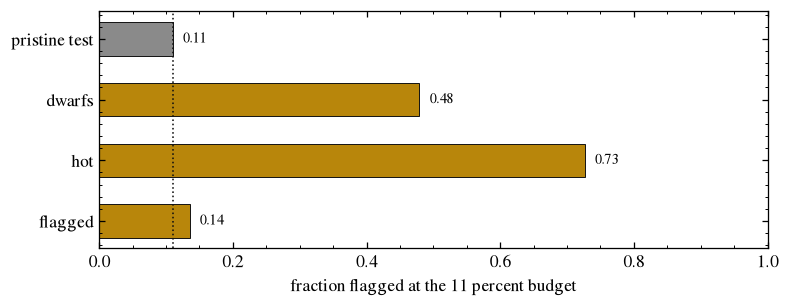

In [12]:
ood = np.load(TAB / "exp7_ood_payload.npz")
snaps10 = np.load(CH_GATED_5E6)["snapshots"]
q10 = snaps10[3 * len(snaps10) // 4:]
take10 = np.linspace(0, len(q10) - 1, 50).astype(int)
model10 = make_model()

@torch.no_grad()
def member_tau(X):
    Xt = torch.tensor(X, device=DEV)
    mus = []
    for st in q10[take10]:
        load_flat(model10, st)
        mus.append(model10(Xt).squeeze(-1).cpu().numpy())
    m = np.stack(mus)
    return m.std(axis=0), m.mean(axis=0)

tau_test10, _ = member_tau(test_Xs)
thresh10 = np.quantile(tau_test10, 0.89)

rows10 = [("pristine test", tau_test10, None)]
for name in ("dwarfs", "hot", "flagged"):
    tau_o, mu_o = member_tau(ood[f"Xs_{name}"])
    rows10.append((name, tau_o, mu_o))

labels, fracs, meds = [], [], []
for name, tau_o, _ in rows10:
    labels.append(name)
    fracs.append(float((tau_o > thresh10).mean()))
    meds.append(float(np.median(tau_o)))

fig, ax = plt.subplots(figsize=(7, 2.8))
ypos = np.arange(len(labels))[::-1]
ax.barh(ypos, fracs, height=0.55, color=[GRAY, ACCENT, ACCENT, ACCENT],
        edgecolor=DARK, lw=0.6)
ax.axvline(0.11, color=DARK, ls=":", lw=1)
ax.set_yticks(ypos, labels)
ax.set_xlabel("fraction flagged at the 11 percent budget")
ax.set_xlim(0, 1)
for y, f in zip(ypos, fracs):
    ax.text(f + 0.015, y, f"{f:.2f}", va="center", fontsize=9)
fig.tight_layout()
for (name, _, _), f, m in zip(rows10, fracs, meds):
    print(f"{name:>14}: flagged {f:.2f}   median tau {m:.4f}")

## 11. Deep nearest neighbors: where neighborhood structure lives

The meeting notes call this project "deep nearest neighbor"; here is one
concrete reading, measured. Run the section-1 k-NN baseline in the
network's learned spaces instead of raw coefficient space: distances in
the first and second hidden layers' activations, averaged over three
posterior members. If the learned space closes the gap between raw k-NN
(0.074) and the network (0.049), the network's value is the
representation, not the readout, the supervised twin of the paper's
latent-space argument.

And because the chain gives a posterior over networks, it gives a
posterior over geometries: for each star, the 10 nearest training
neighbors in layer-2 space, recomputed under 8 different members, agree
or churn. That neighbor stability (mean Jaccard overlap between member
pairs) is a new uncertainty signal, and the dwarfs from section 10 are
the control group that should churn.

Measured: the ladder lands at 0.0742 / 0.0551 / 0.0488 against the
network's 0.0492, the representation carries everything and the readout
adds nothing. The stability probe returns a null with a lesson: median
Jaccard 0.90 for pristine stars and dwarfs alike, under the gated members
and the better-mixed unadjusted control both, so neighbor identity is
essentially posterior-invariant here. Good for deep k-NN as a method (the
geometry is robustly identified, not a lucky draw), but no use as an
uncertainty signal at this budget.

In [13]:
@torch.no_grad()
def embed(X, state, upto):
    load_flat(model10, state)
    h = torch.tensor(X, device=DEV)
    layers = list(model10)
    for lyr in layers[:upto]:
        h = lyr(h)
    return h

@torch.no_grad()
def knn_rmse(train_emb, test_emb, k=10):
    preds = torch.empty(len(test_emb), device=DEV)
    ytr = torch.tensor(train_y, device=DEV)
    for i in range(0, len(test_emb), 1024):
        dist = torch.cdist(test_emb[i:i + 1024], train_emb)
        _, idx = torch.topk(dist, k, largest=False)
        preds[i:i + 1024] = ytr[idx].mean(dim=1)
    return float(((preds - torch.tensor(test_y, device=DEV)) ** 2).mean().sqrt())

members11 = q10[np.linspace(0, len(q10) - 1, 3).astype(int)]
layer_names = ["raw (110)", "layer 1 (64)", "layer 2 (64)"]
uptos = [0, 2, 4]
rmse_by_layer = []
for name, upto in zip(layer_names, uptos):
    vals = []
    for st in (members11 if upto > 0 else members11[:1]):
        tr = embed(train_Xs, st, upto)
        te = embed(test_Xs, st, upto)
        vals.append(knn_rmse(tr, te))
    rmse_by_layer.append(np.mean(vals))
    print(f"k-NN in {name}: RMSE {np.mean(vals):.4f}")
print(f"(network itself: 0.0492, global mean: 0.0927)")

k-NN in raw (110): RMSE 0.0742


k-NN in layer 1 (64): RMSE 0.0551


k-NN in layer 2 (64): RMSE 0.0488
(network itself: 0.0492, global mean: 0.0927)


median stability: test 0.90, dwarfs 0.90
stability vs |error| correlation (test): -0.02


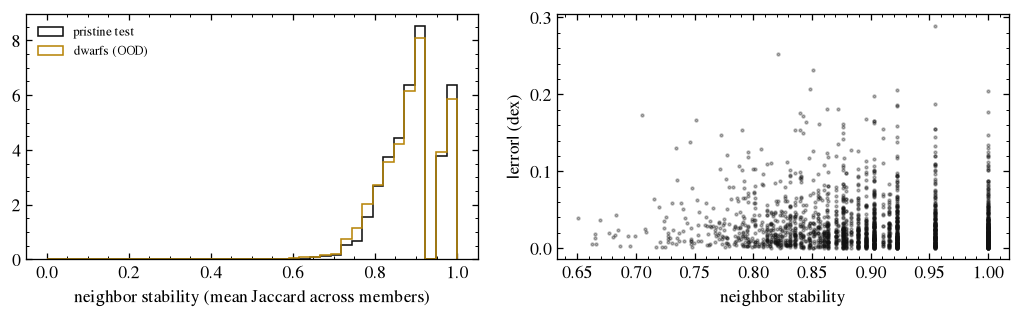

In [14]:
# neighbor stability across members: pristine test vs dwarfs
sub_test = test_Xs[:2000]
sub_dwarf = np.load(TAB / "exp7_ood_payload.npz")["Xs_dwarfs"][:2000]
members_s = q10[np.linspace(0, len(q10) - 1, 8).astype(int)]

@torch.no_grad()
def neighbor_sets(X):
    sets = []
    for st in members_s:
        tr = embed(train_Xs, st, 4)
        qe = embed(X, st, 4)
        dist = torch.cdist(qe, tr)
        _, idx = torch.topk(dist, 10, largest=False)
        sets.append(idx.cpu().numpy())
    return np.stack(sets)          # (members, stars, 10)

def stability(sets):
    m = len(sets)
    out = np.zeros(sets.shape[1])
    pairs = 0
    for a in range(m):
        for b in range(a + 1, m):
            inter = np.array([len(np.intersect1d(sets[a, i], sets[b, i]))
                              for i in range(sets.shape[1])])
            out += inter / (20 - inter)          # Jaccard for two 10-sets
            pairs += 1
    return out / pairs

stab_test = stability(neighbor_sets(sub_test))
stab_dwarf = stability(neighbor_sets(sub_dwarf))

fig, axes = plt.subplots(1, 2, figsize=(9, 2.9))
bins11 = np.linspace(0, 1, 40)
axes[0].hist(stab_test, bins=bins11, histtype="step", color=DARK,
             density=True, label="pristine test")
axes[0].hist(stab_dwarf, bins=bins11, histtype="step", color=ACCENT,
             density=True, label="dwarfs (OOD)")
axes[0].set_xlabel("neighbor stability (mean Jaccard across members)")
axes[0].legend(loc="upper left", fontsize=8)

mu_sub = np.stack([embed(sub_test, st, 5).squeeze(-1).cpu().numpy()
                   for st in members_s]).mean(axis=0)
err_sub = np.abs(mu_sub - test_y[:2000])
axes[1].scatter(stab_test, err_sub, s=3, color=DARK, alpha=0.3)
axes[1].set_xlabel("neighbor stability")
axes[1].set_ylabel("|error| (dex)")
fig.tight_layout()
print(f"median stability: test {np.median(stab_test):.2f}, "
      f"dwarfs {np.median(stab_dwarf):.2f}")
r11 = np.corrcoef(stab_test, err_sub)[0, 1]
print(f"stability vs |error| correlation (test): {r11:+.2f}")

## Findings

**The prior decides what the budget buys.** Under Glorot the chain is
born on its shell and spends the entire budget fitting (RMSE 0.049);
under N(0,1) the same sampler and budget end at 2.9x the misfit, RMSE
0.070, barely at the k-NN level, with calibration twice as bad (z std
7.8 vs 4.4). exp6's 20,000-trajectory walk was not a sampler problem, it
was a prior problem.

**The chain beats the neighbor baseline.** RMSE 0.049 against k-NN's
0.074 and the global-mean 0.093, with a 11,329-parameter MLP.

**Eq. 33 is a diagnostic first, and the chain of record keeps it.** From a prior
draw it is blind at every dt (sigma_sto 26M nats). At the fitted state it
correctly rejects the dt = 1e-4 dynamics wholesale (10M spurious nats per
window). Tuned by the paper's recipe to dt = 5e-6, its acceptance sits
exactly at its own noise ceiling (0.38), coin flips that slow mixing 20x,
collapse the member spread, and still fail to stop the norm creep. The
gated chain is nonetheless the chain of record, and an unadjusted control
arm matching its predictions to one percent (0.0486 vs 0.0492) is the
evidence that the knob-controlled dynamics were already clean. Two
lessons for free: tune acceptance only from a fitted state, and never
read a drift rule without the acceptance next to it, a frozen chain
passes any stationarity test.

**The uncertainties need an intrinsic scatter.** z std about 4 under
either Glorot chain: residuals 0.049 vs claimed 0.010. One extra sampled
parameter s (sigma_i^2 = err_i^2 + s^2) is the obvious next run.

## The bottom line

**Put the prior where sensible networks live and the walk disappears;
keep the Metropolis check and it will tell you, loudly, which step sizes
your minibatch dynamics can defend.**